<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/colab/MiniProject_PokemonWinPrediction_DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GenAI & Machine Learning Bootcamp 2025 - Part Time 2025 - WW Machine Learning & Hackathon Mini Project Pokemon Win Prediction Analysis

https://octopus.developers.institute/courses/collection/124/course/721/section/1960/chapter/4375

In [71]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

print("All imports loaded!")

All imports loaded!


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Pokemon Data Analysis Tutorial.zip to Pokemon Data Analysis Tutorial.zip


In [2]:
!unzip 'Pokemon Data Analysis Tutorial.zip'

Archive:  Pokemon Data Analysis Tutorial.zip
  inflating: Pokemon Data Analysis Tutorial/combats.csv  
  inflating: Pokemon Data Analysis Tutorial/pokemon.csv  
  inflating: Pokemon Data Analysis Tutorial/tests.csv  


In [5]:
!ls

'Pokemon Data Analysis Tutorial'       sample_data
'Pokemon Data Analysis Tutorial.zip'


In [43]:
pok = pd.read_csv('Pokemon Data Analysis Tutorial/pokemon.csv')
com = pd.read_csv('Pokemon Data Analysis Tutorial/combats.csv')
tst = pd.read_csv('Pokemon Data Analysis Tutorial/tests.csv')

In [11]:
print(pok.shape)
print(com.shape)
print(tst.shape)
pok.head()

(800, 12)
(50000, 3)
(10000, 2)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [13]:
com.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [33]:
pok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [44]:
print(pok['Type 1'].unique())
print(pok['Type 2'].unique())

['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']
['Poison' nan 'Flying' 'Dragon' 'Ground' 'Fairy' 'Grass' 'Fighting'
 'Psychic' 'Steel' 'Ice' 'Rock' 'Dark' 'Water' 'Electric' 'Fire' 'Ghost'
 'Bug' 'Normal']


In [45]:
# Fix missing values
pok['Name'].fillna('Primeape', inplace=True)
pok['Type 2'].fillna('None', inplace=True)

In [46]:
#Merging Data sets
pok1 = pok.rename(
    columns=lambda x: x + '_First' if x != '#' else x
)
# Merge First Pokémon stats
df = com.merge(
    pok1,
    left_on='First_pokemon',
    right_on='#',
    how='left',
    suffixes=('', '_First')
)

# Merge Second Pokémon stats
df = df.merge(
    pok1,
    left_on='Second_pokemon',
    right_on='#',
    how='left',
    suffixes=('', '_Second')
)

# Drop duplicate ID columns
df = df.drop(columns=['#', '#_Second'])

In [47]:
print(df.shape)
print(df.columns)
df.head()

(50000, 25)
Index(['First_pokemon', 'Second_pokemon', 'Winner', 'Name_First',
       'Type 1_First', 'Type 2_First', 'HP_First', 'Attack_First',
       'Defense_First', 'Sp. Atk_First', 'Sp. Def_First', 'Speed_First',
       'Generation_First', 'Legendary_First', 'Name_First_Second',
       'Type 1_First_Second', 'Type 2_First_Second', 'HP_First_Second',
       'Attack_First_Second', 'Defense_First_Second', 'Sp. Atk_First_Second',
       'Sp. Def_First_Second', 'Speed_First_Second', 'Generation_First_Second',
       'Legendary_First_Second'],
      dtype='object')


,First_pokemon,Second_pokemon,Winner,Name_First,Type 1_First,Type 2_First,HP_First,Attack_First,Defense_First,Sp. Atk_First,...,Type 1_First_Second,Type 2_First_Second,HP_First_Second,Attack_First_Second,Defense_First_Second,Sp. Atk_First_Second,Sp. Def_First_Second,Speed_First_Second,Generation_First_Second,Legendary_First_Second
0,266,298,298,Larvitar,Rock,Ground,50,64,50,45,...,Grass,Dark,70,70,40,60,40,60,3,False
1,702,701,701,Virizion,Grass,Fighting,91,90,72,90,...,Rock,Fighting,91,129,90,72,90,108,5,True
2,191,668,668,Togetic,Fairy,Flying,55,40,85,80,...,Psychic,None,75,75,75,125,95,40,5,False
3,237,683,683,Slugma,Fire,None,40,40,40,70,...,Dragon,None,77,120,90,60,90,48,5,False
4,151,231,151,Omastar,Rock,Water,70,60,125,115,...,Bug,Rock,20,10,230,10,230,5,2,False


In [49]:
# Count wins
win_counts = com['Winner'].value_counts()

# Combine first and second Pokémon to get all battles
all_pok = pd.concat([com['First_pokemon'], com['Second_pokemon']])
battle_counts = all_pok.value_counts()

#Calculate win percentage
win_percentage = (win_counts / battle_counts * 100).fillna(0).sort_values(ascending=False).round(2)

print(win_percentage.head(10))  # top 10 Pokemon by win rate

155    98.45
513    97.48
704    96.80
20     96.64
154    96.45
477    96.12
727    96.06
717    95.93
165    95.20
350    95.00
Name: count, dtype: float64


In [50]:
# Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage.

# Convert win_percentage to DataFrame
win_df = win_percentage.rename("WinPct").reset_index().rename(columns={"index":"#"})

# Merge with Pokemon stats
pok_win = pok.merge(win_df, on="#", how="left").fillna(0)
pok_win.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,WinPct
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,27.82
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,38.02
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,67.42
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,56.00
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,49.11


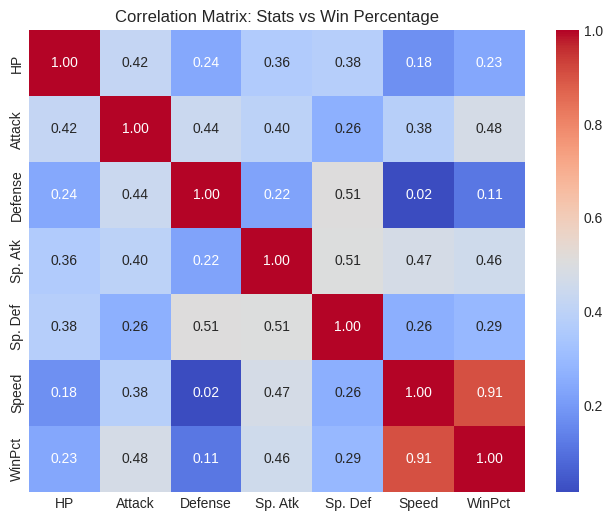

In [52]:
# Create a correlation matrix
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'WinPct']
corr_matrix = pok_win[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Stats vs Win Percentage")
plt.show()

Speed has the strongest correlation with winners!

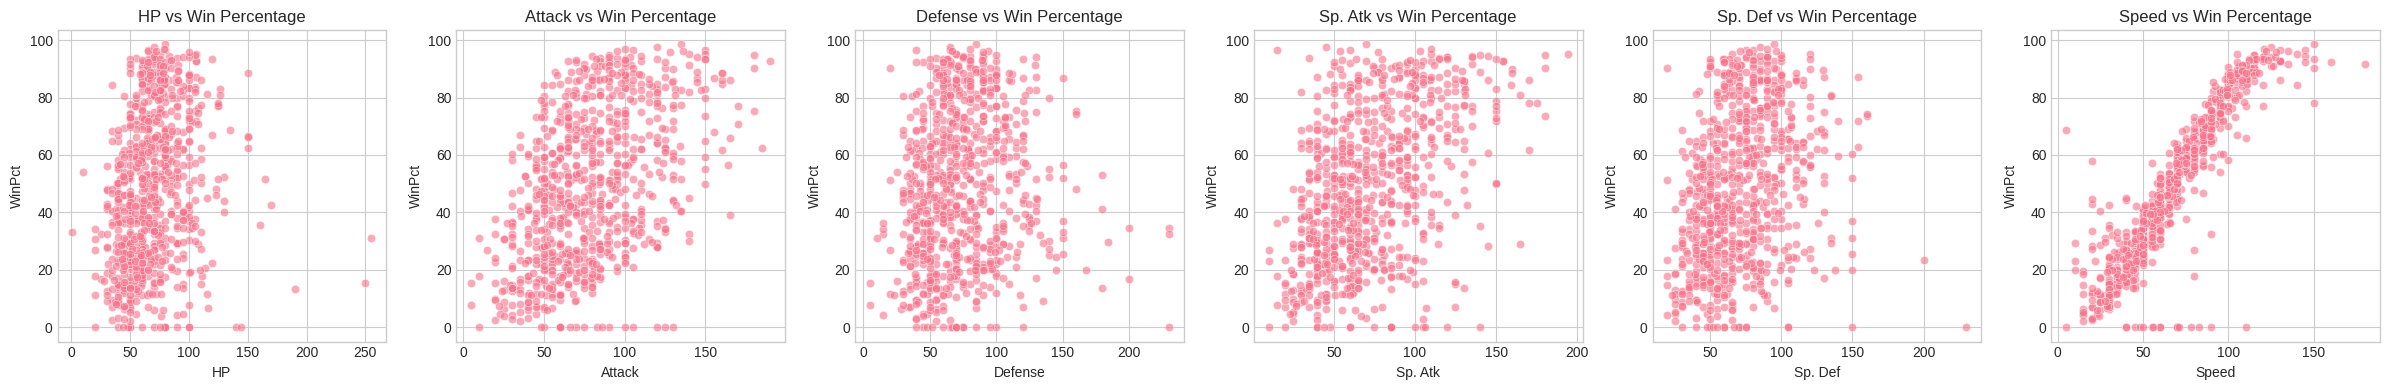

In [62]:
#Plot a Seaborn pairplot for stats vs. win percentage

stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

fig, axes = plt.subplots(1, len(stats), figsize=(4*len(stats), 4))
for i, stat in enumerate(stats):
    sns.scatterplot(
        x=pok_win[stat],
        y=pok_win['WinPct'],
        ax=axes[i],
        alpha=0.6
    )
    axes[i].set_xlabel(stat)
    axes[i].set_ylabel('WinPct')
    axes[i].set_title(f'{stat} vs Win Percentage')

plt.tight_layout()
plt.show()

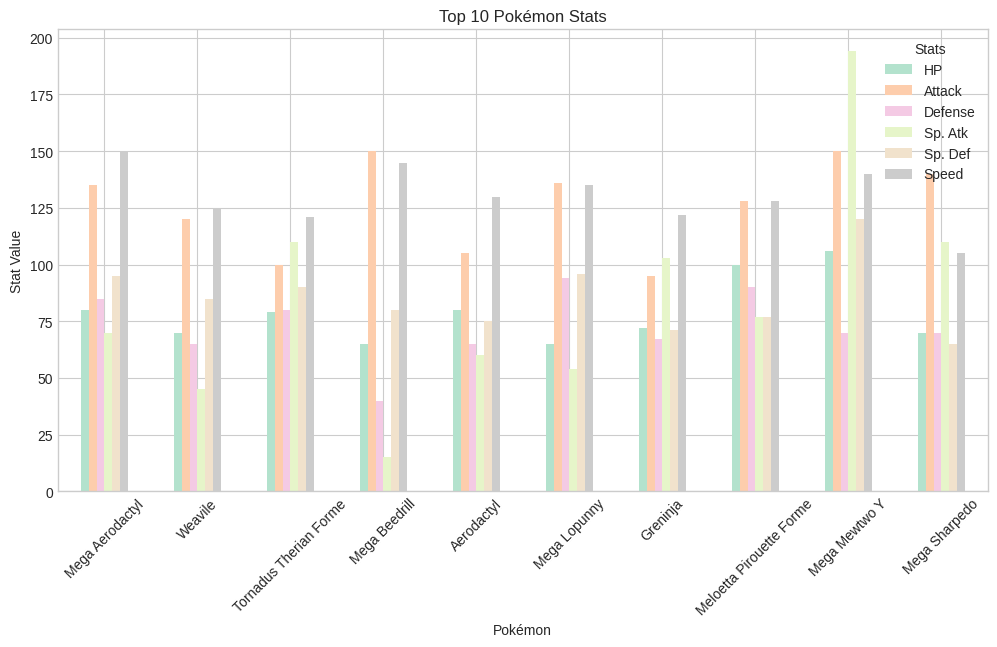

In [69]:
#Analyze the top 10 Pokemon by win percentage and their stats

# Sort by WinPct descending and take top 10
pok_top10 = pok_win.sort_values('WinPct', ascending=False).head(10)

# Set Name as index for plotting
pok_top10_plot = pok_top10.set_index('Name')

# Plot a grouped bar chart of stats
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
pok_top10_plot[stats_cols].plot(kind='bar', figsize=(12,6), colormap='Pastel2')
plt.title("Top 10 Pokémon Stats")
plt.ylabel("Stat Value")
plt.xlabel("Pokémon")
plt.xticks(rotation=45)
plt.legend(title='Stats')
plt.show()

In [ ]:
#Machine Learning

In [109]:
#Split data into training/testing sets (80/20 split)

# Numeric stats as features - Use MULTIPLE REGRESSION
X = pok_win[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
y = pok_win['WinPct']

# Split into 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [112]:
#Train and evaluate 3 regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage.
# Calculate ALL regression metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Train and evaluate
results = {}
for name, model in models.items():
    if name == 'Linear Regression': #Scaling is recommended for Linear Regression
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)
      X_test = scaler.transform(X_test)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {
        'MAE': mae,
        'R2': r2,
        'RMSE': rmse
    }
    # results[name] = mae

# Show evaluations for each model
results_df = pd.DataFrame(results).T  # .T = transpose for models as rows
results_df = results_df.sort_values('MAE').round(2)  # optional: sort by MAE

print("Model performance metrics for MULTIPLE regression:\n")
print(results_df)

Model performance metrics for MULTIPLE regression:

                    MAE    R2   RMSE
Random Forest      5.78  0.85   9.72
Linear Regression  6.49  0.83  10.45
XGBoost            6.56  0.82  10.85


In [113]:
#Let's try SIMPLE REGRESSION - Speed has the strongest correlation with winners

X_s = pok_win[['Speed']]  # double brackets -> DataFrame (2D)
y_s = pok_win['WinPct']

# Split into 80% train / 20% test
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42
)
# Train and evaluate
results_s = {}
for name, model in models.items():
    model.fit(X_train_s, y_train_s)
    y_pred_s = model.predict(X_test_s)
    mae = mean_absolute_error(y_test_s, y_pred_s)
    r2 = r2_score(y_test_s, y_pred_s)
    rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
    results_s[name] = {
        'MAE': mae,
        'R2': r2,
        'RMSE': rmse
    }

# Show evaluations for each model
results_df_s = pd.DataFrame(results_s).T  # .T = transpose for models as rows
results_df_s = results_df_s.sort_values('MAE').round(2)  # optional: sort by MAE

print("Model performance metrics for SIMPLE dependency:\n")
print(results_df_s)


Model performance metrics for SIMPLE dependency:

                    MAE    R2   RMSE
Random Forest      6.69  0.81  11.03
XGBoost            6.75  0.81  11.02
Linear Regression  6.83  0.81  11.15


In [114]:
# Compare simple vs multiple regression
print("=" * 55)
print("  SIMPLE vs MULTIPLE REGRESSION — COMPARISON")
print("=" * 55)
print(f"{'Metric':<15} {'Simple (1 feature)':<22} {'Multiple (6 features)'}")
print("-" * 55)
for name, model in models.items():
    print(f"\nModel: {name}")
    print()
    r2_multi = results_df.loc[name, 'R2']
    r2_s = results_df_s.loc[name, 'R2']
    mae_multi = results_df.loc[name, 'MAE']
    mae_s = results_df_s.loc[name, 'MAE']
    rmse_multi = results_df.loc[name, 'RMSE']
    rmse_s = results_df_s.loc[name, 'RMSE']
    print(f"{'R²':<15} {r2_s:<22.4f} {r2_multi:.4f}")
    print(f"{'RMSE':<15} {rmse:<22.4f} {rmse_multi:.4f}")
    print(f"{'MAE':<15} {mae:<22.4f} {mae_multi:.4f}")

    r2_improvement = ((r2_multi - r2) / r2) * 100
    print(f"R² improvement: {r2_improvement:+.1f}%")
    print("More features → Better predictions!" if r2_multi > r2 else "Hmm, not always more = better!\n")
    print("-" * 55)



  SIMPLE vs MULTIPLE REGRESSION — COMPARISON
Metric          Simple (1 feature)     Multiple (6 features)
-------------------------------------------------------

Model: Linear Regression

R²              0.8100                 0.8300
RMSE            11.0239                10.4500
MAE             6.7463                 6.4900
R² improvement: +2.1%
More features → Better predictions!
-------------------------------------------------------

Model: Random Forest

R²              0.8100                 0.8500
RMSE            11.0239                9.7200
MAE             6.7463                 5.7800
R² improvement: +4.6%
More features → Better predictions!
-------------------------------------------------------

Model: XGBoost

R²              0.8100                 0.8200
RMSE            11.0239                10.8500
MAE             6.7463                 6.5600
R² improvement: +0.9%
More features → Better predictions!
-------------------------------------------------------


In this case, as the number of parameters increases, the prediction improves